<a href="https://colab.research.google.com/github/abdullahkashif09/E-commerce/blob/main/Zameen_com.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Phase 1: Import Libraries and Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("/content/Property - Property.csv")
data.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,347795,8,https://www.zameen.com/Property/lahore_model_t...,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,7/17/2019,Real Biz International,Usama Khan
1,482892,48,https://www.zameen.com/Property/lahore_multan_...,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10/6/2018,Khan Estate,mohsinkhan and B
2,555962,75,https://www.zameen.com/Property/eden_eden_aven...,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,7/3/2019,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,562843,3821,https://www.zameen.com/Property/gulberg_2_gulb...,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,4/4/2019,NaN,NaN
4,686990,3522,https://www.zameen.com/Property/allama_iqbal_t...,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,4/4/2019,NaN,NaN


In [ ]:
data.tail()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
191388,17468383,174,https://www.zameen.com/Property/islamabad_i_8_...,Upper Portion,70000,I-8,Islamabad,Islamabad Capital,33.668497,73.074160,0,12.4 Marla,For Rent,3,7/24/2019,Property World,Zafran
191389,17468384,174,https://www.zameen.com/Property/islamabad_i_8_...,Upper Portion,40000,I-8,Islamabad,Islamabad Capital,33.668497,73.074160,0,12.4 Marla,For Rent,2,7/24/2019,Property World,Zafran
191390,17468482,167,https://www.zameen.com/Property/islamabad_g_10...,House,160000,G-10,Islamabad,Islamabad Capital,33.676104,73.013842,6,1 Kanal,For Rent,6,7/24/2019,Azaan Associates,Usman Rehman
191391,17468586,339,https://www.zameen.com/Property/dha_defence_dh...,Flat,25000,DHA Defence,Islamabad,Islamabad Capital,33.527944,73.161392,2,2.7 Marla,For Rent,2,7/24/2019,New National Properties,TALHA MIAN AHMAD
191392,17468660,3421,https://www.zameen.com/Property/i_10_i_10_2_i_...,Upper Portion,26000,I-10,Islamabad,Islamabad Capital,33.649779,73.029385,1,0 Marla,For Rent,3,7/24/2019,Select Homes,"Qaiser Shahzad, Chaudhary Waseem"


In [ ]:
data.shape

(191393, 17)

In [ ]:
data.columns

Index(['property_id', 'location_id', 'page_url', 'property_type', 'price',
       'location', 'city', 'province_name', 'latitude', 'longitude', 'baths',
       'area', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191393 entries, 0 to 191392
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    191393 non-null  int64  
 1   location_id    191393 non-null  int64  
 2   page_url       191393 non-null  object 
 3   property_type  191393 non-null  object 
 4   price          191393 non-null  int64  
 5   location       191393 non-null  object 
 6   city           191393 non-null  object 
 7   province_name  191393 non-null  object 
 8   latitude       191393 non-null  float64
 9   longitude      191393 non-null  float64
 10  baths          191393 non-null  int64  
 11  area           191393 non-null  object 
 12  purpose        191393 non-null  object 
 13  bedrooms       191393 non-null  int64  
 14  date_added     191393 non-null  object 
 15  agency         144014 non-null  object 
 16  agent          144013 non-null  object 
dtypes: float64(2), int64(5), obje

In [ ]:
data.describe()

,property_id,location_id,price,latitude,longitude,baths,bedrooms
count,1.913930e+05,191393.000000,1.913930e+05,191393.000000,191393.000000,191393.000000,191393.000000
mean,1.573170e+07,4224.580350,1.644655e+07,30.104593,71.572992,2.865956,3.171516
std,2.215249e+06,3719.125201,3.416412e+07,3.645941,3.080463,2.435332,1.952403
min,8.657500e+04,1.000000,0.000000e+00,11.052446,25.906027,0.000000,0.000000
25%,1.511867e+07,1057.000000,8.000000e+04,24.972287,67.152597,0.000000,2.000000
50%,1.676385e+07,3233.000000,7.300000e+06,31.463563,73.077743,3.000000,3.000000
75%,1.715282e+07,7182.000000,1.800000e+07,33.550869,74.228218,4.000000,4.000000
max,1.769386e+07,14246.000000,2.000000e+09,73.184088,80.161430,403.000000,68.000000


Phase 2: Data Cleaning and Preparation

In [ ]:
missing_values = data.isnull().sum()
print(missing_values)


property_id          0
location_id          0
page_url             0
property_type        0
price                0
location             0
city                 0
province_name        0
latitude             0
longitude            0
baths                0
area                 0
purpose              0
bedrooms             0
date_added           0
agency           47379
agent            47380
dtype: int64


In [ ]:
data.drop(columns="location_id",inplace=True)
data.head()


,property_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,347795,https://www.zameen.com/Property/lahore_model_t...,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,7/17/2019,Real Biz International,Usama Khan
1,482892,https://www.zameen.com/Property/lahore_multan_...,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10/6/2018,Khan Estate,mohsinkhan and B
2,555962,https://www.zameen.com/Property/eden_eden_aven...,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,7/3/2019,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,562843,https://www.zameen.com/Property/gulberg_2_gulb...,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,4/4/2019,NaN,NaN
4,686990,https://www.zameen.com/Property/allama_iqbal_t...,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,4/4/2019,NaN,NaN


In [ ]:
categorical_cols = data.select_dtypes(include=['object', 'string']).columns
data[categorical_cols] = data[categorical_cols].fillna('Unknown')
numerical_cols = data.select_dtypes(include=['number']).columns
data[numerical_cols] = data[numerical_cols].fillna(data[numerical_cols].mean())
data.isna().sum()

,0
property_id,0
page_url,0
property_type,0
price,0
location,0
city,0
province_name,0
latitude,0
longitude,0
baths,0


In [ ]:
data["area_in_marla"] = None
data.head()

,property_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,area_in_marla
0,347795,https://www.zameen.com/Property/lahore_model_t...,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,7/17/2019,Real Biz International,Usama Khan,None
1,482892,https://www.zameen.com/Property/lahore_multan_...,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10/6/2018,Khan Estate,mohsinkhan and B,None
2,555962,https://www.zameen.com/Property/eden_eden_aven...,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,7/3/2019,Shahum Estate 2,"Babar Hameed, Raja Omar",None
3,562843,https://www.zameen.com/Property/gulberg_2_gulb...,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,4/4/2019,Unknown,Unknown,None
4,686990,https://www.zameen.com/Property/allama_iqbal_t...,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,4/4/2019,Unknown,Unknown,None


In [ ]:
data[["area_value", "area_unit"]] = data["area"].str.split(" ", expand=True)
data["area_value"] = data["area_value"].replace("Unknown", None)
data["area_value"] = data["area_value"].str.replace(",","").astype(float)
data["area_in_marla"] = data["area_value"]
unit = data["area_unit"].str.lower() == "kanal"
data.loc[unit, "area_in_marla"] = data.loc[unit, "area_value"] * 20
data.drop(["area_unit","area_value"], axis=1, inplace=True)
data.head()

,property_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,area_in_marla
0,347795,https://www.zameen.com/Property/lahore_model_t...,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,7/17/2019,Real Biz International,Usama Khan,120.0
1,482892,https://www.zameen.com/Property/lahore_multan_...,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10/6/2018,Khan Estate,mohsinkhan and B,20.0
2,555962,https://www.zameen.com/Property/eden_eden_aven...,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,7/3/2019,Shahum Estate 2,"Babar Hameed, Raja Omar",9.0
3,562843,https://www.zameen.com/Property/gulberg_2_gulb...,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,4/4/2019,Unknown,Unknown,20.0
4,686990,https://www.zameen.com/Property/allama_iqbal_t...,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,4/4/2019,Unknown,Unknown,11.0


Phase 3: Outlier Detection

<Axes: >

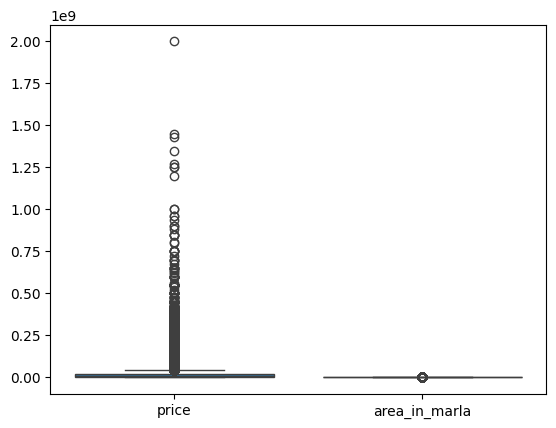

In [ ]:
sns.boxplot(data=data[["price", "area_in_marla"]])


In [ ]:
data["price"].quantile([0.25,0.5,0.75])
Q1 = data["price"].quantile(0.25)
Q3 = data["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_outliers = data[(data["price"]<lower_bound) | (data["price"]>upper_bound)]
iqr_outliers["price"].value_counts()

,count
price,
45000000,1329
55000000,850
50000000,738
65000000,671
60000000,568
...,...
216000000,1
93800000,1
143000000,1


In [ ]:
data["area_in_marla"].quantile([0.25,0.5,0.75])
Q1 = data["area_in_marla"].quantile(0.25)
Q3 = data["area_in_marla"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_outliers = data[(data["area_in_marla"]<lower_bound) | (data["area_in_marla"]>upper_bound)]
iqr_outliers["area_in_marla"].value_counts()

,count
area_in_marla,
40.0,3886
24.0,1896
26.0,1602
80.0,657
32.0,355
...,...
118.0,1
3060.0,1
4000.0,1


<Axes: >

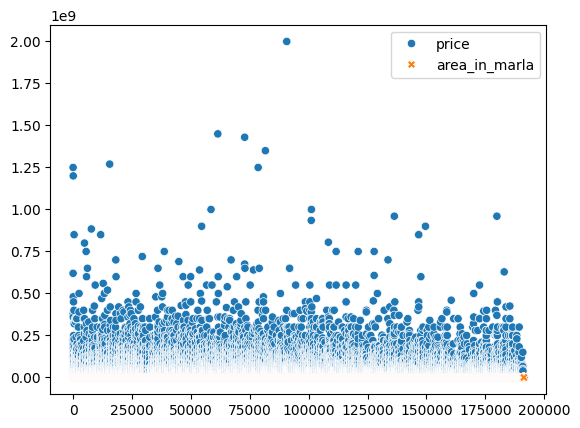

In [ ]:
sns.scatterplot(data=data[["price", "area_in_marla"]])

A. Univariate Analysis (One Variable)

<Axes: xlabel='price', ylabel='Count'>

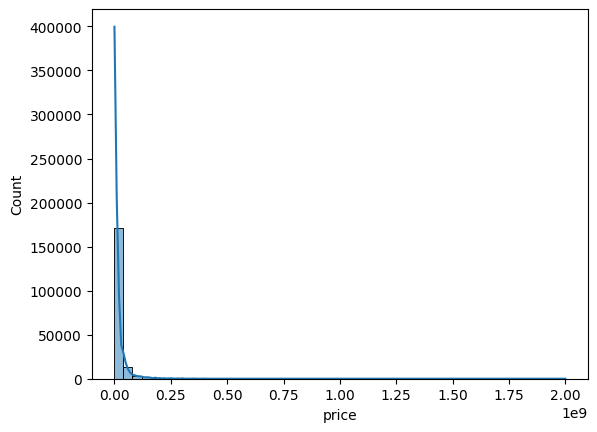

In [ ]:
sns.histplot(data["price"], bins=50, kde=True)


<Axes: xlabel='price', ylabel='Count'>

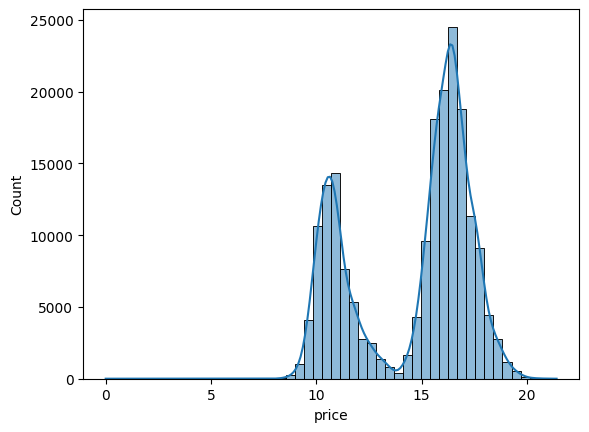

In [ ]:
sns.histplot(np.log1p(data["price"]), bins=50, kde=True)

<Axes: ylabel='city'>

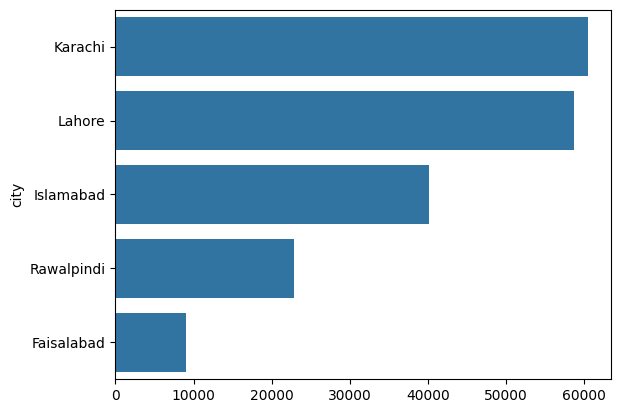

In [ ]:
city_counts = data["city"].value_counts()
sns.barplot(x=city_counts.values, y=city_counts.index)

<Axes: >

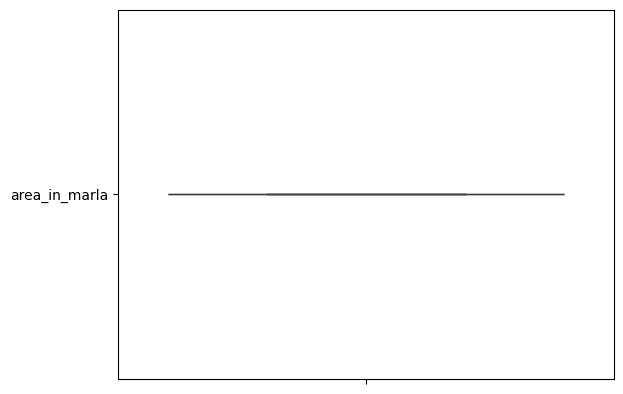

In [ ]:
sns.boxplot("area_in_marla")

B. Bivariate Analysis (Two Variables)

<Axes: xlabel='city', ylabel='price'>

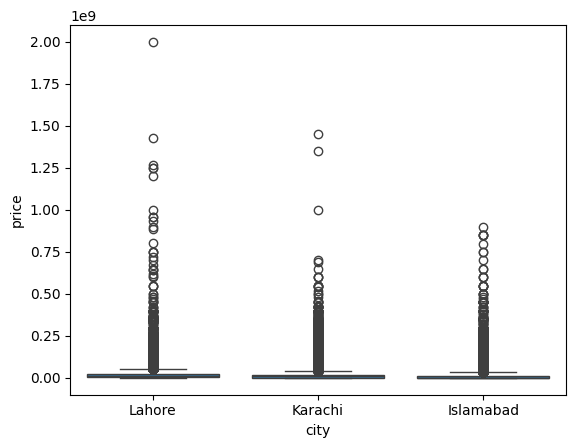

In [ ]:
top3_cities = data[data["city"].isin(["Karachi", "Lahore", "Islamabad"])]
sns.boxplot(x="city", y="price", data=top3_cities)

<Axes: xlabel='area_in_marla', ylabel='price'>

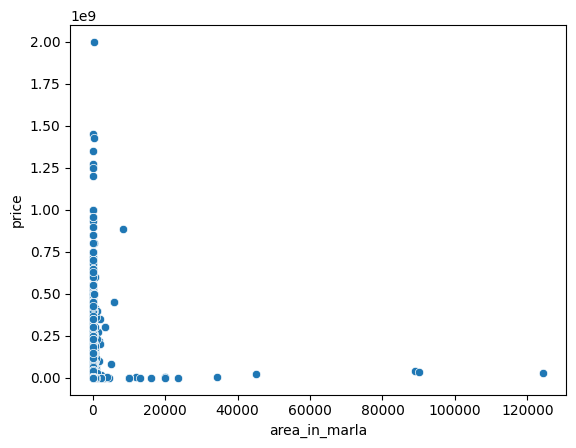

In [ ]:
sns.scatterplot(x="area_in_marla", y="price", data=data)


Does the price increase linearly with area?
No
Are there properties with small area but huge prices (potential errors or prime
commercial spots)?
Yes

<Axes: xlabel='baths', ylabel='price'>

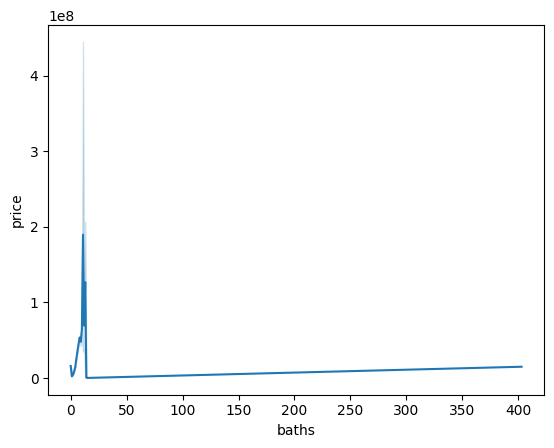

In [ ]:
sns.lineplot(x="baths", y="price", data=data)

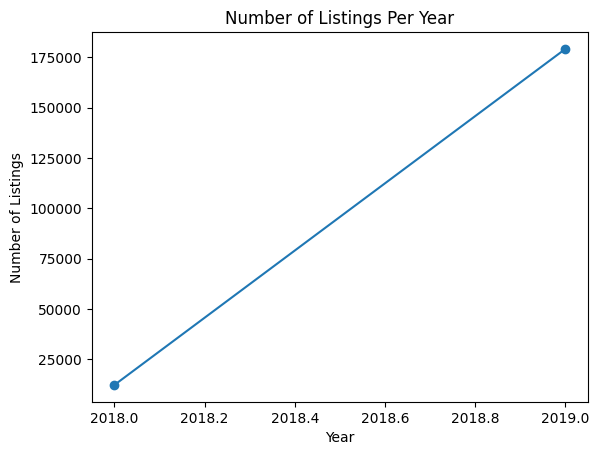

In [ ]:
data["date_added"] = pd.to_datetime(data["date_added"], errors="coerce")
data["year"] = data["date_added"].dt.year
yearly_counts = data.groupby("year").size()
yearly_counts.plot(marker='o')
plt.title("Number of Listings Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Listings")
plt.show()

C. Multivariate Analysis (Three+ Variables)

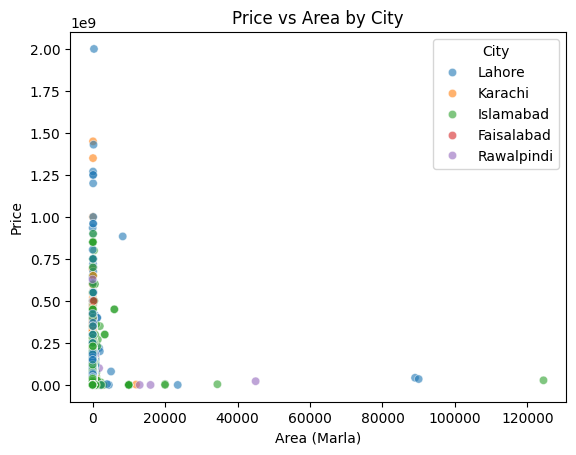

In [ ]:
sns.scatterplot(
    x="area_in_marla",
    y="price",
    hue="city",
    data=data,
    alpha=0.6
)
plt.title("Price vs Area by City")
plt.xlabel("Area (Marla)")
plt.ylabel("Price")
plt.legend(title="City")
plt.show()

In [ ]:
data.corr(numeric_only=True)

,property_id,price,latitude,longitude,baths,bedrooms,area_in_marla,year
property_id,1.000000,-0.039687,0.023294,0.043368,-0.100241,-0.065099,0.003975,0.378536
price,-0.039687,1.000000,-0.084885,-0.049790,0.219297,0.303069,0.021809,0.016298
latitude,0.023294,-0.084885,1.000000,0.915495,0.047043,0.025288,0.008298,0.041195
longitude,0.043368,-0.049790,0.915495,1.000000,0.090028,0.072582,0.007487,0.049397
baths,-0.100241,0.219297,0.047043,0.090028,1.000000,0.669057,0.004605,-0.032543
bedrooms,-0.065099,0.303069,0.025288,0.072582,0.669057,1.000000,0.007573,-0.019122
area_in_marla,0.003975,0.021809,0.008298,0.007487,0.004605,0.007573,1.000000,0.002665
year,0.378536,0.016298,0.041195,0.049397,-0.032543,-0.019122,0.002665,1.000000


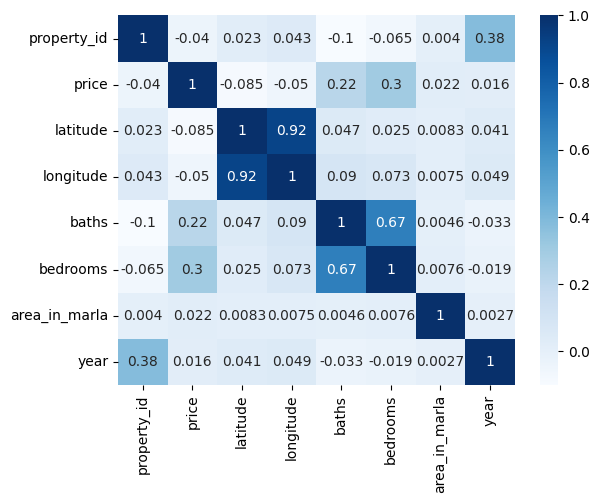

In [ ]:
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="Blues")
plt.show()

o Which variable has the strongest positive correlation with price?
area, bedrooms and bathrooms

<Axes: xlabel='property_type', ylabel='price'>

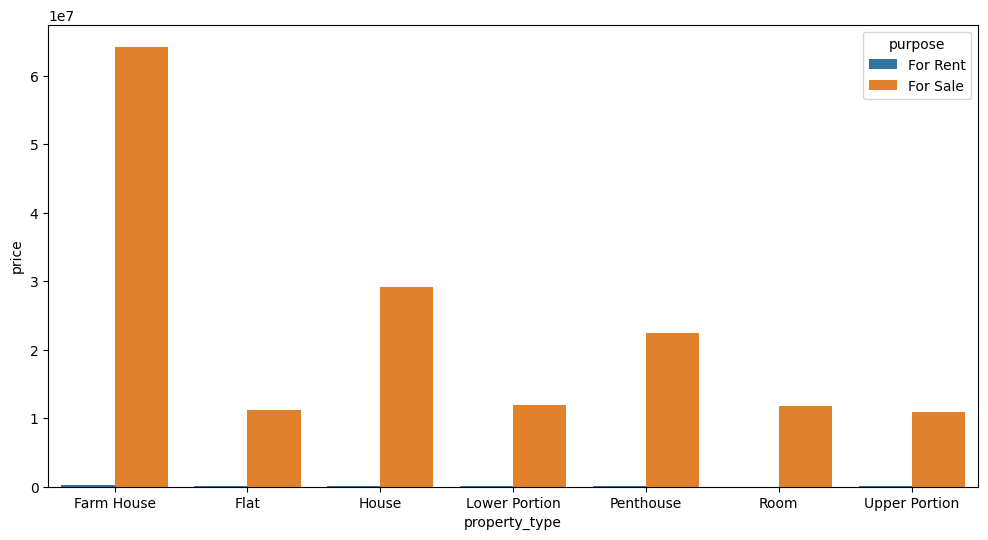

In [ ]:
avg_price = data.groupby(["property_type", "purpose"])["price"].mean().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(
    x="property_type",
    y="price",
    hue="purpose",
    data=avg_price,
)


Phase 5: Business Questions (Q&A)

Which city shows the highest growth in high-value properties (properties above a certain
price threshold) over the years?
Ans: Karachi

<Axes: xlabel='year', ylabel='count'>

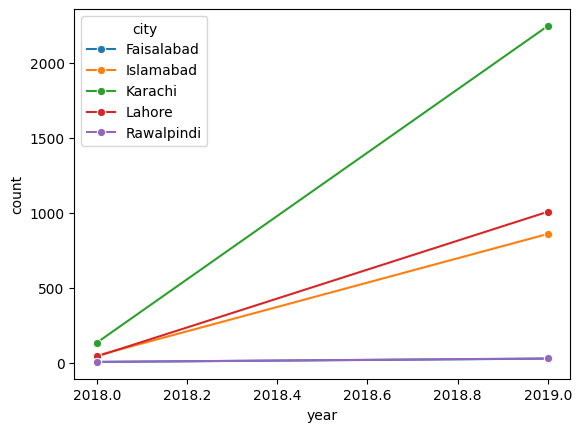

In [ ]:
data["date_added"] = pd.to_datetime(data["date_added"], errors="coerce")
data["year"] = data["date_added"].dt.year
high_value = data[data["price"] > 100_000_000]
high_value = high_value[high_value["city"].notna() & high_value["year"].notna()]
city_year_counts = high_value.groupby(["city", "year"]).size().reset_index(name="count")
sns.lineplot(data=city_year_counts, x="year", y="count", hue="city", marker="o")


What are the most popular property types in each city, and how has this preference
changed over time?
Ans: House in all cities except KArachi where flats are popular. The preferences remain same over two years


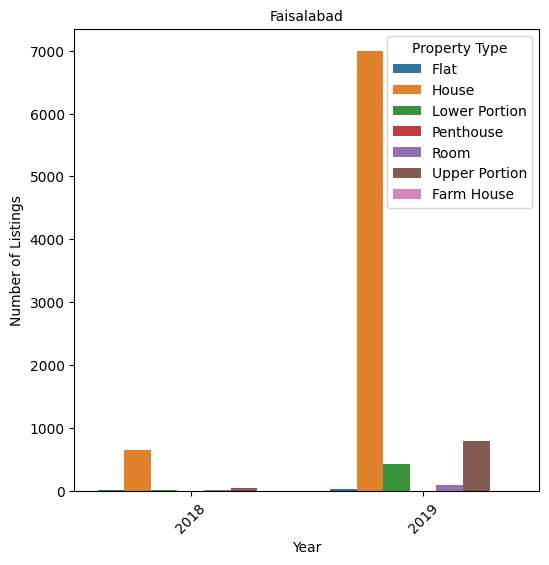

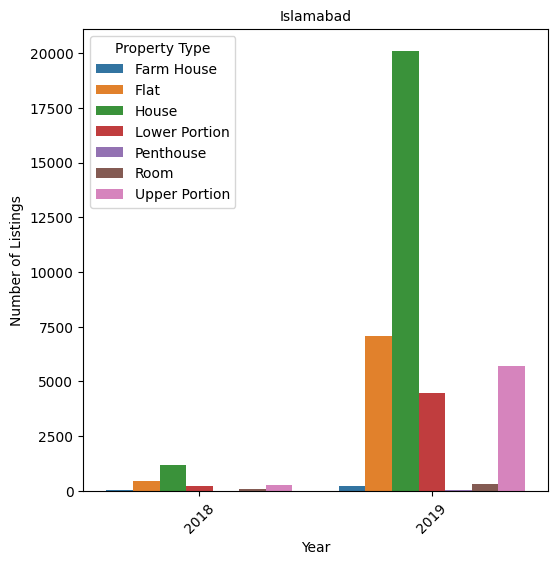

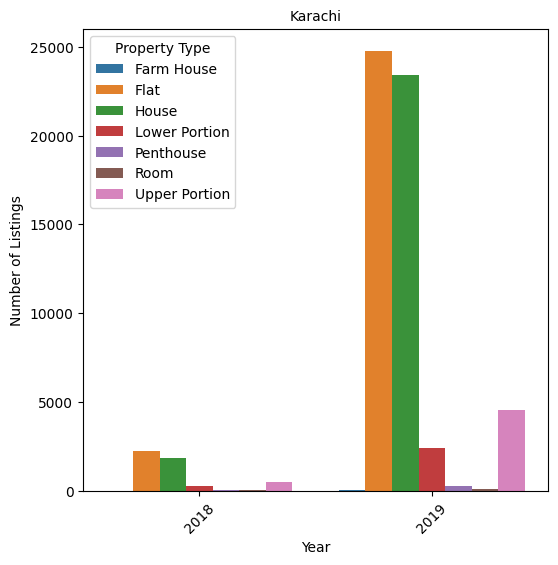

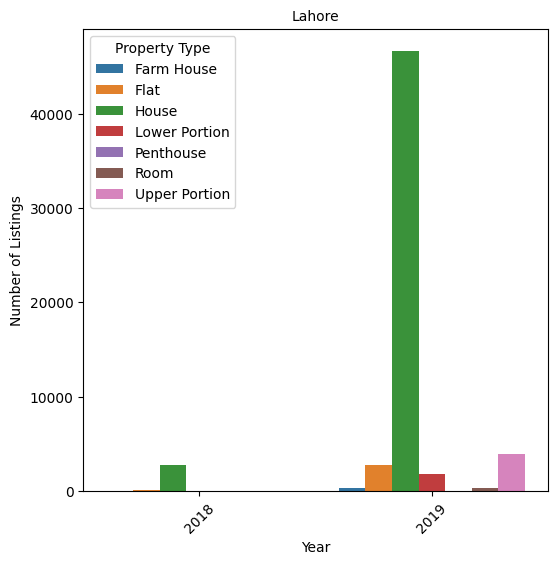

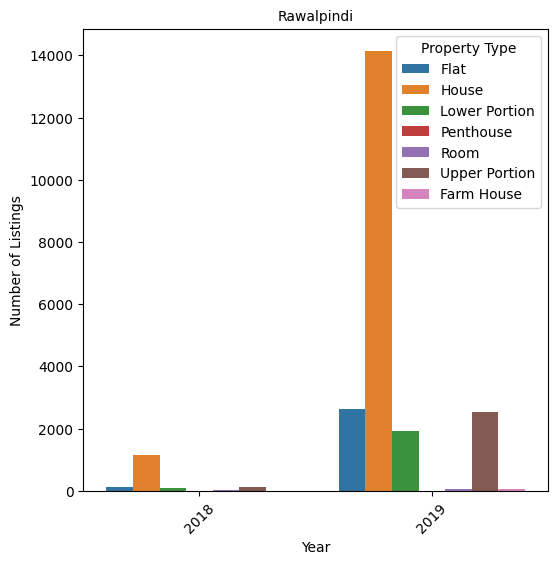

In [ ]:
data["date_added"] = pd.to_datetime(data["date_added"], errors="coerce")
data["year"] = data["date_added"].dt.year
city_property_year_counts = data.groupby(["city", "year", "property_type"]).size().reset_index(name="count")
cities = city_property_year_counts["city"].unique()
for city in cities:
    city_data = city_property_year_counts[city_property_year_counts["city"] == city]
    plt.figure(figsize=(6,6))
    sns.barplot(
        data=city_data,
        x="year",
        y="count",
        hue="property_type",
         )
    plt.title(city, fontsize=10)
    plt.xlabel("Year", fontsize=10)
    plt.ylabel("Number of Listings", fontsize=10)
    plt.xticks(rotation=45)
    plt.legend(title="Property Type")
plt.show()


How do property prices vary with the number of bedrooms across different cities and
property types?

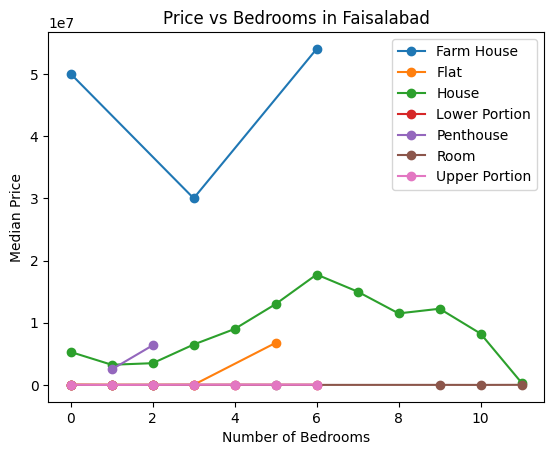

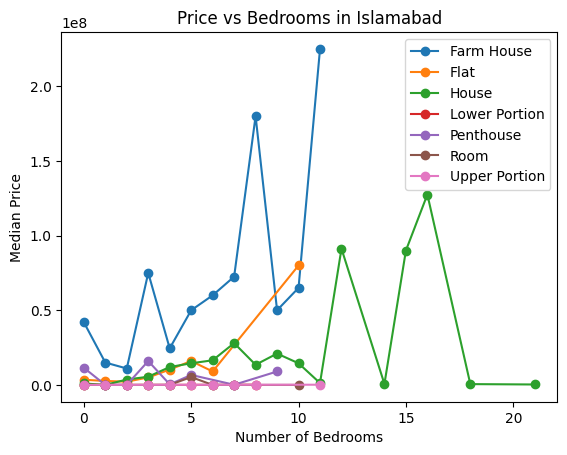

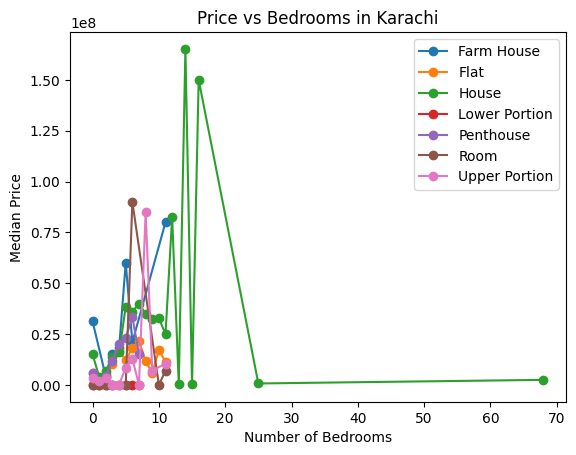

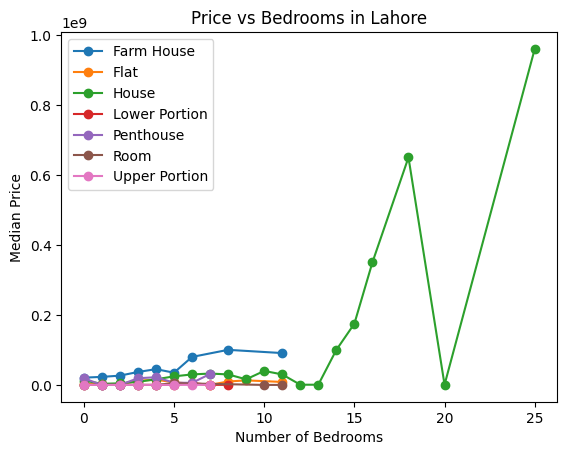

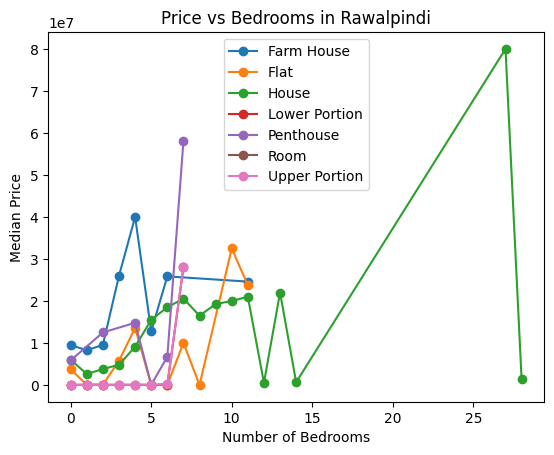

In [ ]:
grouped = (
    data
    .groupby(["city", "property_type", "bedrooms"])["price"]
    .median()
    .reset_index()
)
cities = grouped["city"].unique()
for city in cities:
    city_data = grouped[grouped["city"] == city]

    plt.figure()

    for ptype in city_data["property_type"].unique():
        type_data = city_data[city_data["property_type"] == ptype]

        plt.plot(
            type_data["bedrooms"],
            type_data["price"],
            marker='o',
            label=ptype
        )

    plt.title(f"Price vs Bedrooms in {city}")
    plt.xlabel("Number of Bedrooms")
    plt.ylabel("Median Price")
    plt.legend()
    plt.show()

Which agencies have the most listings in high-demand areas (specific locations or
cities)?

In [ ]:
top_cities = data["city"].value_counts().head(5).index
high_demand_data = data[data["city"].isin(top_cities)]
agency_city_counts = (
    high_demand_data
    .groupby(["city", "agency"])
    .size()
    .reset_index(name="listing_count")
    .sort_values(["city", "listing_count"], ascending=[True, False])
)

print(agency_city_counts.head(20))


           city                                             agency  \
265  Faisalabad                                            Unknown   
42   Faisalabad                              Al Noor Estate Agency   
45   Faisalabad                             Al Qasim Estate Agency   
76   Faisalabad                                Azeem Estate Agency   
185  Faisalabad                                       Moosa Estate   
53   Faisalabad                       Al-Qasim Estate & Developers   
173  Faisalabad                             Meezan Property Dealer   
55   Faisalabad                     Al-Siddiq Estate and Developer   
77   Faisalabad                                      BM Associates   
67   Faisalabad                              Aslam Property Dealer   
89   Faisalabad                             Chanab Property Centre   
236  Faisalabad                                   Saim Real Estate   
172  Faisalabad                               Makkah Property Deal   
176  Faisalabad     

Is there a seasonal trend in property listings (e.g., are more houses listed in specific
months)?

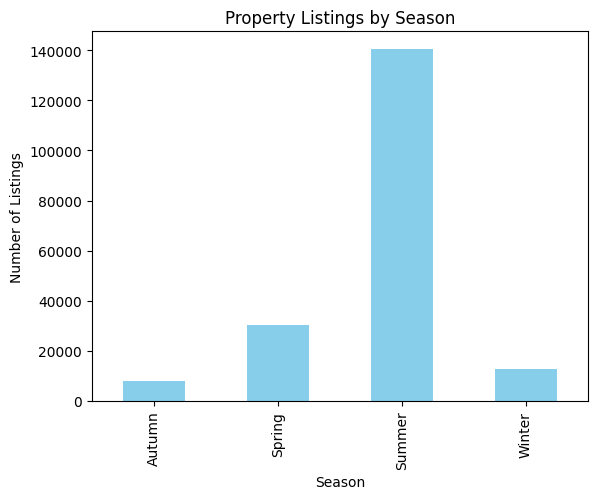

In [ ]:
data['date_added'] = pd.to_datetime(data['date_added'], dayfirst=True)
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'
data['season'] = data['date_added'].dt.month.apply(month_to_season)
season_counts = data['season'].value_counts().sort_index()
season_counts.plot(kind='bar', color='skyblue')
plt.xlabel("Season")
plt.ylabel("Number of Listings")
plt.title("Property Listings by Season")
plt.show()

How do the sizes of properties (in SqFt/Marla) correlate with their prices across different
cities and property types?

In [ ]:
correlation = data['price'].corr(data['area_in_marla'])
print(f"Overall correlation between price and area: {correlation:.2f}")
city_corr = data.groupby('city').apply(lambda x: x['price'].corr(x['area_in_marla']))
print(city_corr)

Overall correlation between price and area: 0.02
city
Faisalabad    0.467276
Islamabad     0.020911
Karachi       0.099823
Lahore        0.026600
Rawalpindi    0.017415
dtype: float64


/tmp/ipython-input-2221867808.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  city_corr = data.groupby('city').apply(lambda x: x['price'].corr(x['area_in_marla']))


Which property types are more prevalent in certain provinces, and how does this
distribution impact property prices?

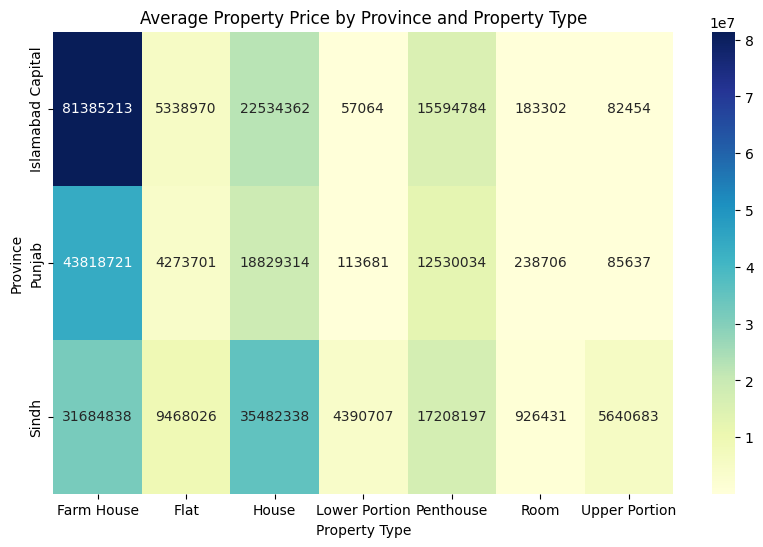

In [ ]:
type_counts = data.groupby(['province_name', 'property_type']).size().unstack(fill_value=0)
avg_prices = data.groupby(['province_name', 'property_type'])['price'].mean().unstack()
plt.figure(figsize=(10,6))
sns.heatmap(avg_prices, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Property Price by Province and Property Type")
plt.ylabel("Province")
plt.xlabel("Property Type")
plt.show()

How does the number of bathrooms influence property prices in different cities?

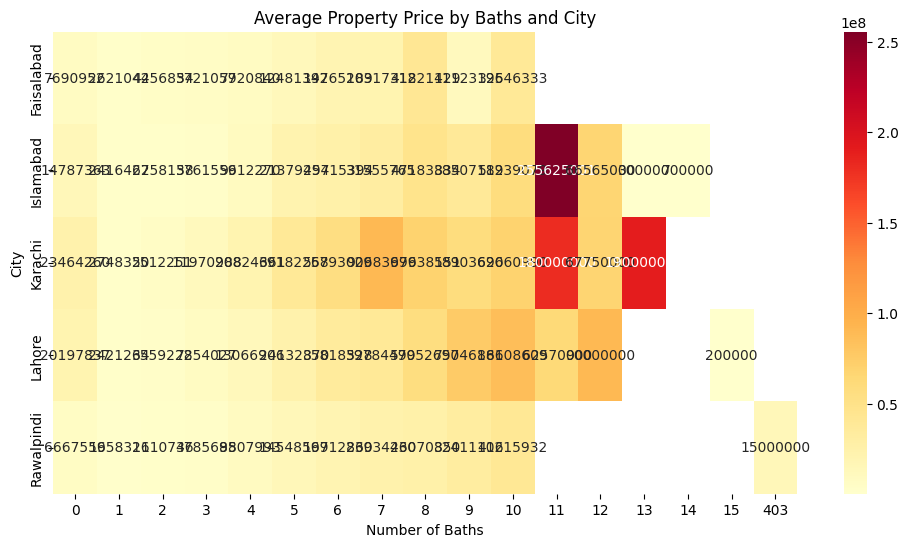

In [ ]:
avg_price_by_bathroom = data.groupby(['city', 'baths'])['price'].mean().unstack()
plt.figure(figsize=(12,6))
sns.heatmap(avg_price_by_bathroom, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Average Property Price by Baths and City")
plt.ylabel("City")
plt.xlabel("Number of Baths")
plt.show()

What is the distribution of properties listed for different purposes (e.g., For Sale vs. For
Rent) across various cities?

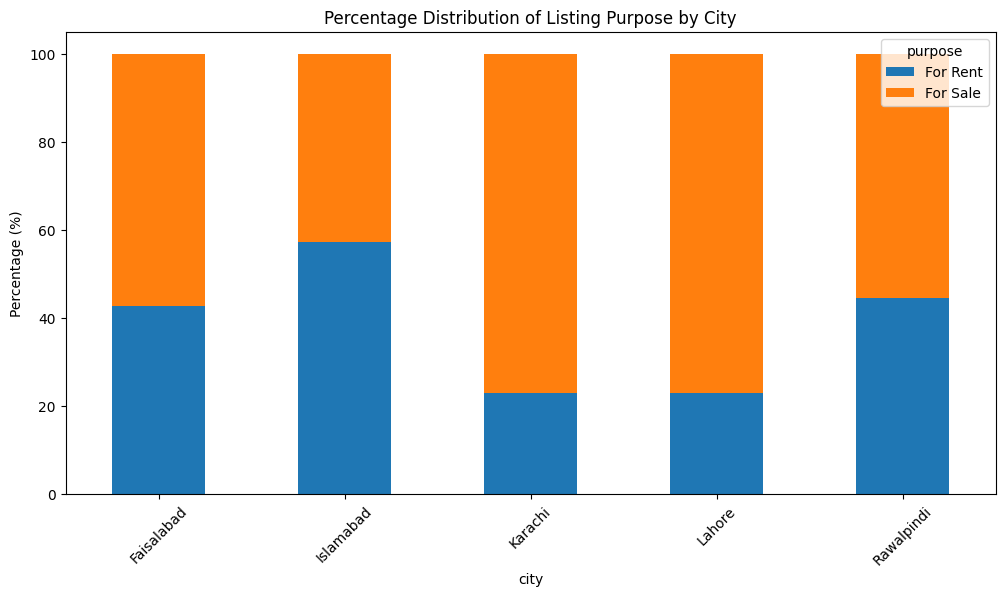

In [ ]:
purpose_counts = data.groupby(['city', 'purpose']).size().unstack(fill_value=0)
purpose_percent = purpose_counts.div(purpose_counts.sum(axis=1), axis=0) * 100
purpose_percent.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Percentage Distribution of Listing Purpose by City")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.show()


Which agents are most active in high-value property markets?

In [ ]:
top_agents_value = (
    high_value.groupby('agent')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_agents_value)

agent
Unknown                119930300000
Abdul Latif Shah        18667800000
Tariq Mehmood           10340000000
Agha Farooq              8887500000
Asif                     8844000000
S. Kazim Raza            7830000000
Ehtisham                 7233600000
Irfan Rehman Khan        5535000000
Bukhari Properties       5445500000
Mohammad Amjad Khan      5445000000
Name: price, dtype: int64
